In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from unseen import stability
from unseen import independence
from unseen import similarity
from unseen import fileio

import utils

In [2]:
region = 'se-2030'
model = 'CanESM5'
model_infile = '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_CanESM5-dcppA-hindcast_196101-201701_MJJ_se-2030.nc'

## Read spatially averaged daily mean surface wind speed data

#### Observations

In [3]:
obs_infile = f'/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1980-2025_MJJ_{region}.nc'
ds_obs = xr.open_dataset(obs_infile)
ds_obs = ds_obs.compute()
sfcWind_obs_data = ds_obs['sfcWind'].values

#### Model data

In [4]:
ds_model = xr.open_dataset(model_infile)
ds_model = ds_model.compute()

In [5]:
ds_model

<xarray.Dataset> Size: 9MB
Dimensions:    (init_date: 57, ensemble: 20, lead_time: 920)
Coordinates:
  * ensemble   (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * lead_time  (lead_time) int64 7kB 0 1 2 3 4 5 6 ... 914 915 916 917 918 919
  * init_date  (init_date) object 456B 1961-05-01 00:00:00 ... 2017-05-01 00:...
    time       (lead_time, init_date) object 420kB 1961-05-01 12:00:00 ... 20...
Data variables:
    sfcWind    (init_date, ensemble, lead_time) float64 8MB 2.104 ... 5.883
Attributes: (12/53)
    CCCma_model_hash:            Unknown
    CCCma_parent_runid:          d2a-asm-e01
    CCCma_pycmor_hash:           13db8596c37129e414cad7ae31f2927ca8f5dd39
    CCCma_runid:                 d2a196101e01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1961:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/06d13276-8392-455a-90a3-8583122...
    variable_id:                 sfcWind
    variant_label:               r1i1p2f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

## Calculate the 10th percentile

In [6]:
sfcWind_model_data = ds_model['sfcWind'].stack({'sample': ['ensemble', 'init_date', 'lead_time']}).values

In [7]:
pctl10_obs = np.percentile(sfcWind_obs_data, 10)
print(pctl10_obs)

2.424089104089355


In [8]:
pctl10_model = np.percentile(sfcWind_model_data, 10)
print(pctl10_model)

2.4840857141088244


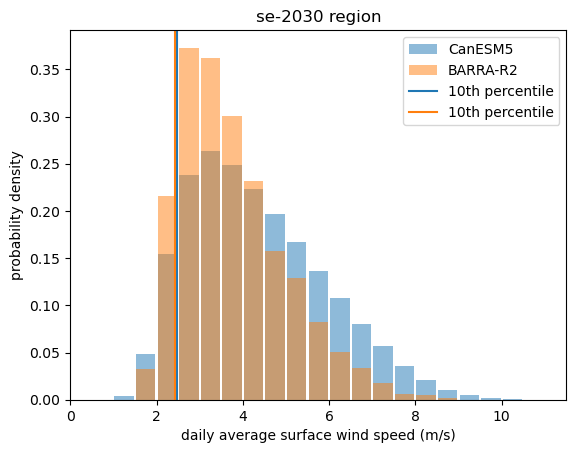

In [9]:
bins = np.arange(0, 12.5, 0.5)
plt.hist(sfcWind_model_data, bins=bins, density=True, rwidth=0.9, label=model, color='tab:blue', alpha=0.5)
plt.hist(sfcWind_obs_data, bins=bins, density=True, rwidth=0.9, label='BARRA-R2', color='tab:orange', alpha=0.5)
plt.axvline(pctl10_model, color='tab:blue', label='10th percentile')
plt.axvline(pctl10_obs, color='tab:orange', label='10th percentile')
plt.xlabel('daily average surface wind speed (m/s)')
plt.ylabel('probability density')
plt.title(f'{region} region')
plt.xlim(0, 11.5)
plt.legend()
plt.show()

## Calculate annual maximum wind drought duration (WDDx)

#### Observations

In [10]:
wddx_obs = utils.calc_wddx_obs(ds_obs, pctl10_obs)

In [11]:
years = wddx_obs['event_start'].dt.year.values
wddx_obs_df = pd.DataFrame(index=years)
wddx_obs_df['WDDx'] = wddx_obs['event_length'].values
wddx_obs_df['start_date'] = wddx_obs['event_start'].dt.strftime('%Y-%m-%d')
wddx_obs_df.sort_values(['WDDx'], ascending=False).head(n=5)

,WDDx,start_date
2010,8.0,2010-05-14
1992,7.0,1992-05-15
2008,6.0,2008-05-08
2024,6.0,2024-05-22
1995,5.0,1995-05-28


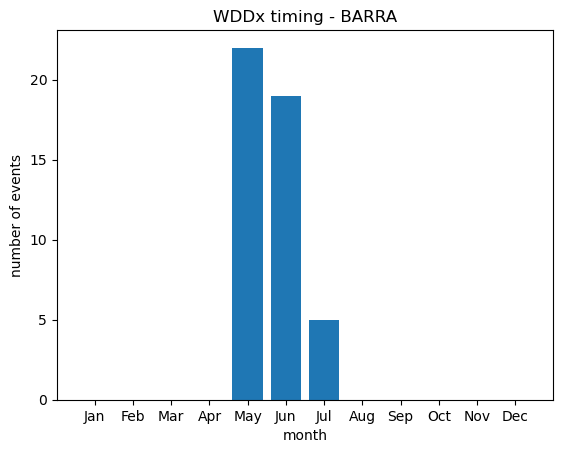

In [12]:
utils.plot_timing(wddx_obs['event_start'], 'BARRA')

#### Models

In [13]:
wddx_model = utils.calc_wddx_model(ds_model, pctl10_model)

In [14]:
wddx_model

<xarray.Dataset> Size: 274kB
Dimensions:       (ensemble: 20, init_date: 57, lead_time: 10)
Coordinates:
  * ensemble      (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
  * init_date     (init_date) object 456B 1961-05-01 00:00:00 ... 2017-05-01 ...
    time          (ensemble, init_date, lead_time) object 91kB 1961-01-01 00:...
  * lead_time     (lead_time) int64 80B 1 2 3 4 5 6 7 8 9 10
Data variables:
    event_length  (ensemble, init_date, lead_time) float64 91kB 5.0 2.0 ... 4.0
    event_start   (ensemble, init_date, lead_time) object 91kB 1961-06-28 12:...

In [15]:
wddx_model_df = wddx_model.stack({'sample': ['ensemble', 'init_date', 'lead_time']}).to_dataframe().reset_index(drop=True)
top_events = wddx_model_df.sort_values(['event_length'], ascending=False).head(n=5)
top_events

,event_length,event_start,time,ensemble,init_date,lead_time
1445,13.0,1996-05-01 12:00:00,1996-01-01 00:00:00,2,1991-05-01 00:00:00,6
6951,12.0,1973-07-10 12:00:00,1973-01-01 00:00:00,12,1972-05-01 00:00:00,2
9553,11.0,2007-07-09 12:00:00,2007-01-01 00:00:00,16,2004-05-01 00:00:00,4
11039,10.0,1990-05-10 12:00:00,1990-01-01 00:00:00,19,1981-05-01 00:00:00,10
1685,10.0,2020-06-05 12:00:00,2020-01-01 00:00:00,2,2015-05-01 00:00:00,6


In [16]:
utils.find_dcpp_data(top_events, model, pctl10_model, region)

13.0 day event starting 1996-05-01: initialisation year 1990, ensemble member r3i1p2f1
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1990-r3i1p2f1/day/pr
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1990-r3i1p2f1/day/zg
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1990-r3i1p2f1/day/sfcWind
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1990-r3i1p2f1/day/psl
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1990-r3i1p2f1/day/ua
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1990-r3i1p2f1/day/tasmax
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1990-r3i1p2f1/AERday/zg500
12.0 day event starting 1973-07-10: initialisation year 1971, ensemble member r13i1p2f1
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1971-r13i1p2f1/day/pr
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5/dcppA-hindcast/s1971-r13i1p2f1/day/sfcWind
/g/data/oi10/replicas/CMIP6/DCPP/CCCma/CanESM5

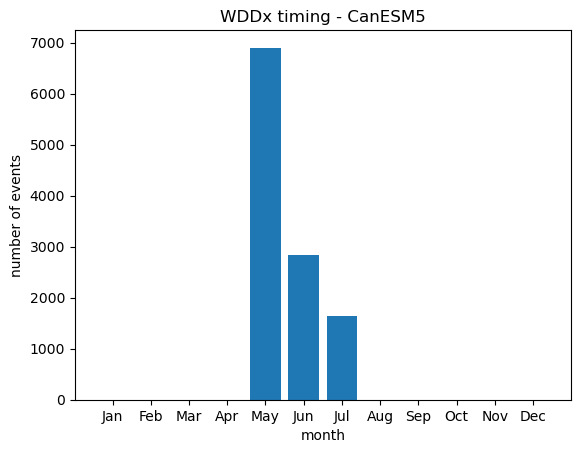

In [17]:
utils.plot_timing(wddx_model['event_start'], model)

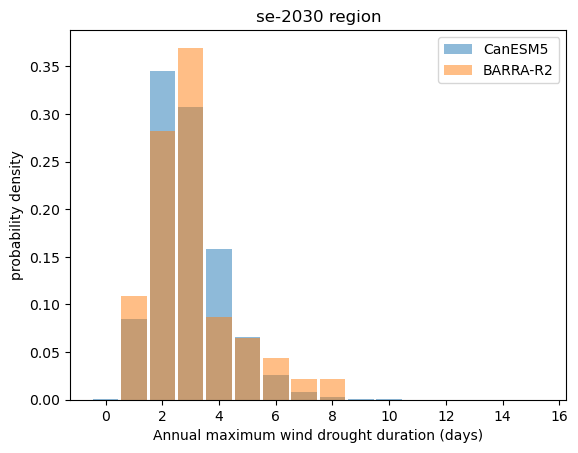

In [18]:
bins = np.arange(-0.5, 16.5, 1)
plt.hist(
    wddx_model['event_length'].values.flatten(),
    bins=bins,
    density=True,
    rwidth=0.9,
    label=model,
    color='tab:blue',
    alpha=0.5
)
plt.hist(
    wddx_obs['event_length'].values,
    bins=bins,
    density=True,
    rwidth=0.9,
    label='BARRA-R2',
    color='tab:orange',
    alpha=0.5
)
plt.xlabel('Annual maximum wind drought duration (days)')
plt.ylabel('probability density')
plt.title(f'{region} region')
plt.legend()
plt.show()

In [19]:
print(np.nanmax(wddx_model['event_length'].values))

13.0


In [20]:
print(np.max(wddx_obs['event_length'].values))

8.0


## Fidelity tests

#### Similarity test

We're looking for a KS-test p-value > 0.05. That means that the null hypothesis (i.e. that the two samples are from the same population) cannot be rejected. In other words, it means that the model and observational WDDx data are statistically similar.

In [21]:
ds_similarity = similarity.similarity_tests(
    wddx_model['event_length'],
    wddx_obs['event_length'],
)

In [22]:
ds_similarity['ks_pval'].values

array(0.99971235, dtype=float32)

#### Independence test

If you are interested in calculating the likelihood of a particular WDDx value, you need to make sure your samples are indepdent. 

To identify the lead time from which the ensemble members can be considered inpedendent, we use a permutation test to determine whether the correlation between ensemble members at a given lead time is sufficiently close to zero. For example, if the first lead time for which the correlation value falls between the dashed lines in the image below was 2, then we would drop lead time one from the analysis and calculate likelihoods using lead time 2 onwards.

In [23]:
ds_indep = independence.run_tests(
    wddx_model['event_length'],
    confidence_interval=0.95,
    n_resamples=1000
)

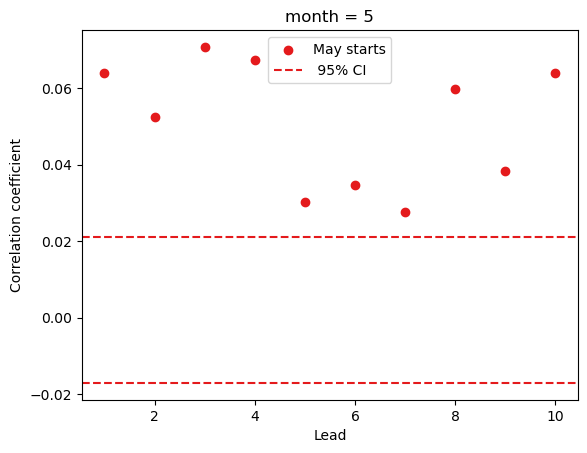

In [24]:
independence.point_plot(ds_indep)

#### Stability

Stability testing gives an indication of any trend or drift in the model data.

Unfortunately the distribution plots look a bit lumpy for categorical data like WDDx as (it's better for continuous data), but the return periods are smooth.

/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/g/data/xv83/dbi599/miniconda3/envs/unseen/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


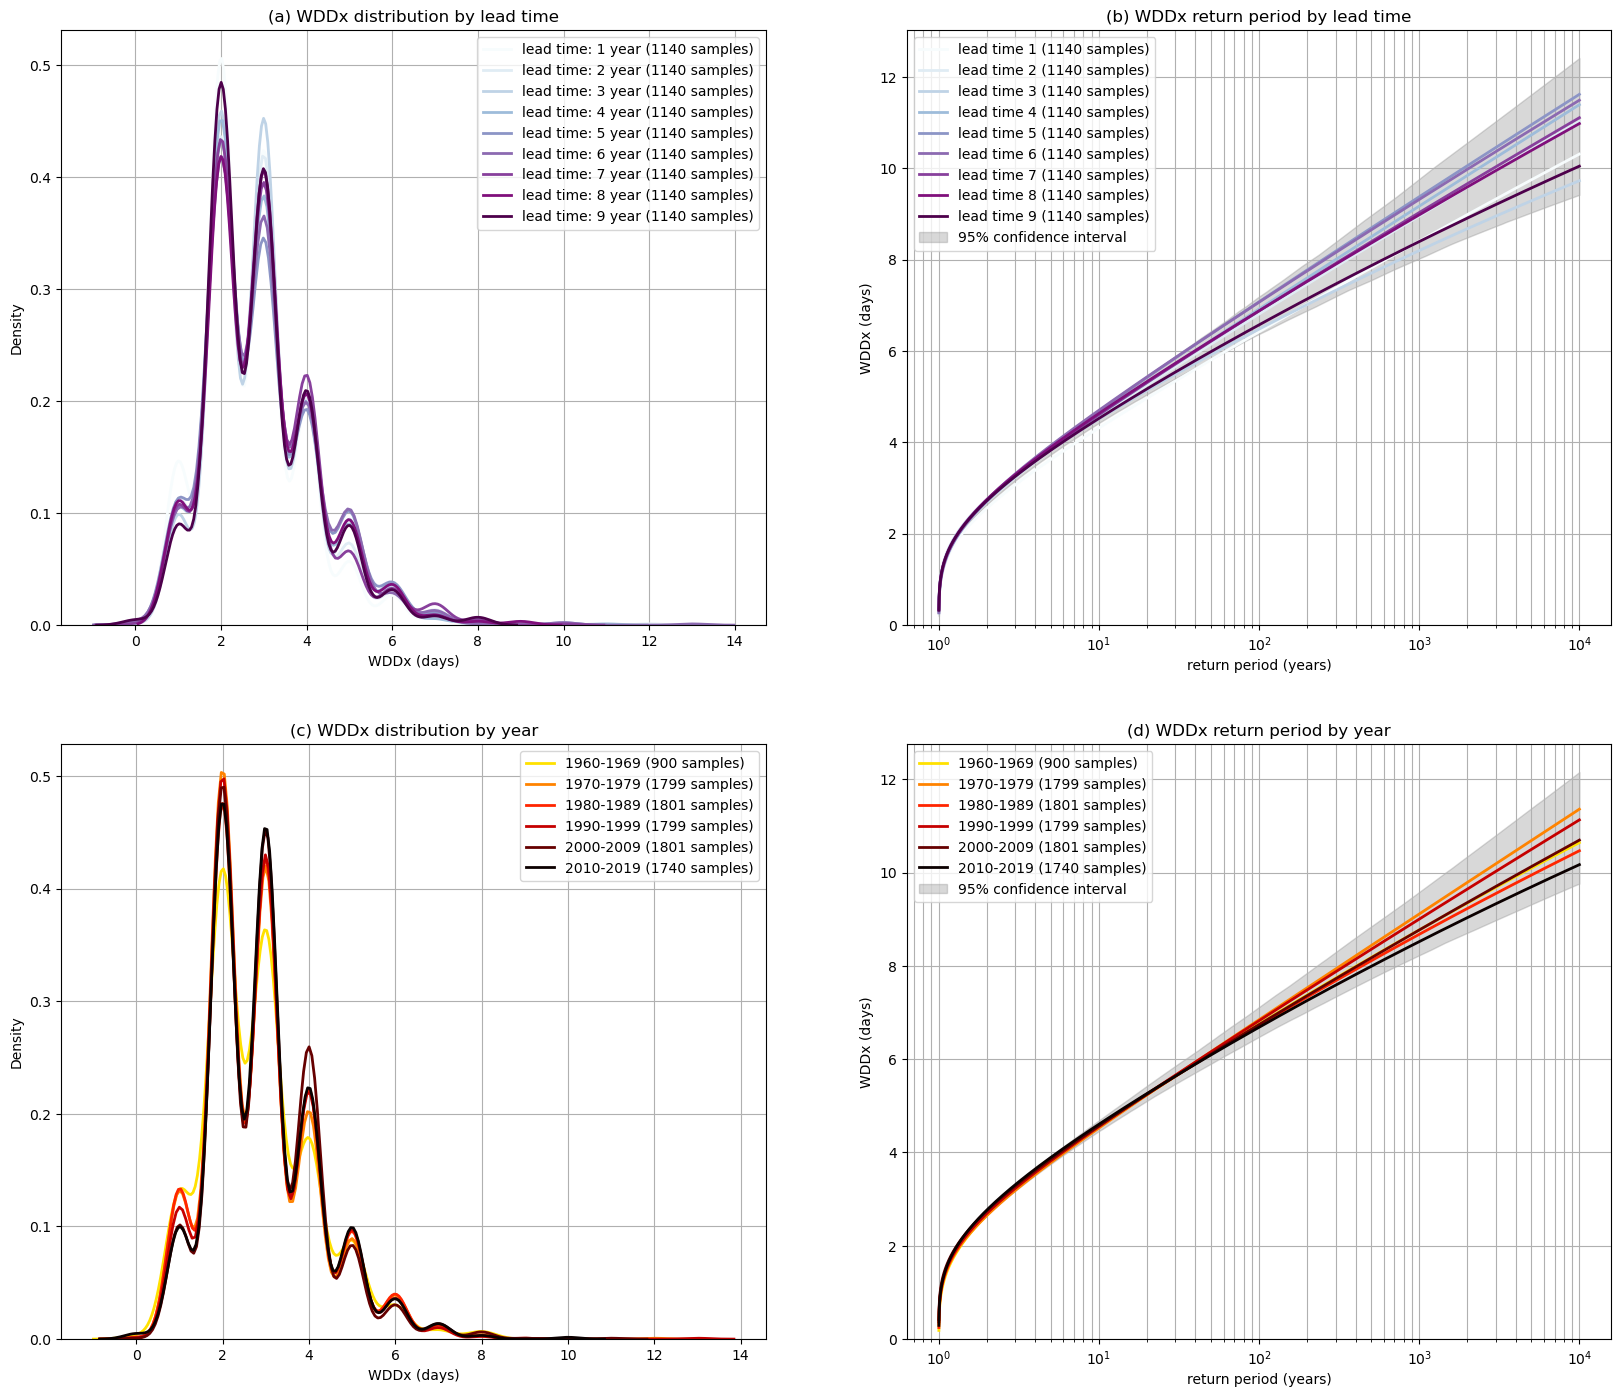

In [25]:
stability.create_plot(
    wddx_model['event_length'],
    'WDDx',
    [1960, 1970, 1980, 1990, 2000, 2010],
    return_method='gev',
    units='WDDx (days)',
    uncertainty=True,
)   